In [9]:
!pip install -q -r requirements.txt

## HAGAN UN .env con esta clave 
WANBD_API_KEY=196adb8a58546f7f94a3bea8a60c00e523de1d0a

Configuración de tamaño de las nuevas imágenes

In [2]:
import os
from PIL import Image
from tqdm import tqdm


def convert_image(path, output_path, size=(128, 128)):
    img = Image.open(path).convert("RGB")  
    img = img.resize(size, Image.BILINEAR)  # resize suave
    img.save(output_path)


funcion para crear nuevas imágenes 

In [3]:
def convert_dataset(root_dir, output_dir, size=(128, 128)):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        
        print(f"\nclase: {class_name}")

        for split in ["train", "test"]:
            split_path = os.path.join(class_path, split)
            if not os.path.isdir(split_path):
                continue

            for subclass in os.listdir(split_path):
                subclass_path = os.path.join(split_path, subclass)
                if not os.path.isdir(subclass_path):
                    continue

                # crear carpeta destino
                dest_folder = os.path.join(output_dir, class_name, split, subclass)
                os.makedirs(dest_folder, exist_ok=True)

                # convertir fotos
                for img_name in tqdm(os.listdir(subclass_path), desc=f"{class_name}/{split}/{subclass}"):
                    src_path = os.path.join(subclass_path, img_name)
                    dst_path = os.path.join(dest_folder, img_name)

                    try:
                        convert_image(src_path, dst_path, size=size)
                    except:
                        print(f"foto dañada: {src_path}")


correr la conversión de las imágenes

In [4]:
input_dataset = "data/"          # dir original
output_dataset = "mvtec_rgb128"  # nombre carpeta nueva

convert_dataset(input_dataset, output_dataset)



clase: cable


cable/test/poke_insulation: 100%|██████████| 10/10 [00:00<00:00, 13.20it/s]



clase: capsule


capsule/test/squeeze: 100%|██████████| 20/20 [00:01<00:00, 13.14it/s]



clase: screw


screw/test/thread_top: 100%|██████████| 23/23 [00:01<00:00, 21.24it/s]



clase: transistor


transistor/test/misplaced: 100%|██████████| 10/10 [00:00<00:00, 10.49it/s]


Ejemplo de como quedó la conversión

Size: (128, 128)
Mode: RGB


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

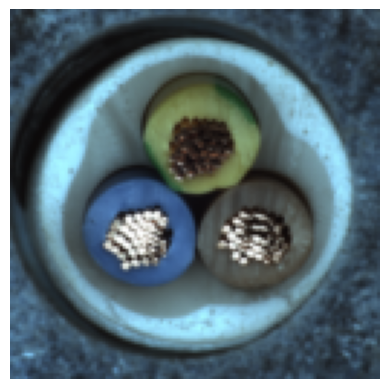

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = "mvtec_rgb128/cable/train/good/000.png"
img = Image.open(sample_path)

print("Size:", img.size)
print("Mode:", img.mode)

plt.imshow(img)
plt.axis("off")


In [ ]:
#esto tiene mi cuenta, despues la cambiamos
import wandb
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("WANBD_API_KEY")

if api_key:
    os.environ["WANDB_API_KEY"] = api_key
    wandb.login(key=api_key)
else:
    print("WANDB_API_KEY no está")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\mauri\_netrc
wandb: Currently logged in as: mauu (mauu-tec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
#from torchvision import transforms

#transform = transforms.Compose([
    #transforms.ToTensor(),
#])

#esto creo que no sera necesario, despues lo borramos si no se usa


In [ ]:
from src.data import MVTecDataset

train_ds = MVTecDataset("mvtec_rgb128", "train", "cable")
test_ds  = MVTecDataset("mvtec_rgb128", "test",  "cable")

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))

# Debe imprimir SOLO "good" en train
unique_train_defects = set([d for _,_,d in train_ds])
print("Train defect types:", unique_train_defects)

# Test debe mostrar varios tipos
unique_test_defects = set([d for _,_,d in test_ds])
print("Test defect types:", unique_test_defects)


Train samples: 224
Test samples: 150
Train defect types: {'good'}
Test defect types: {'good', 'poke_insulation', 'missing_cable', 'missing_wire', 'cable_swap', 'cut_outer_insulation', 'bent_wire', 'cut_inner_insulation', 'combined'}


In [17]:
!python src/train.py dataset.class_name=cable loss.type=l1


c:\Users\mauri\miniconda3\envs\tarea05\lib\site-packages\hydra\_internal\defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
c:\Users\mauri\miniconda3\envs\tarea05\lib\site-packages\pytorch_lightning\utilities\parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
wandb: Currently logged in as: mauu (mauu-tec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run hpcrjmka
wandb: 


Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.95it/s]
                                                                           

Training: |          | 0/? [00:00<?, ?it/s]
Training: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 7/7 [00:06<00:00,  1.06it/s, v_num=jmka]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]

Validation DataLoader 0:  20%|██        | 1/5 [00:00<00:01,  3.13it/s]

Validation DataLoader 0:  40%|████      | 2/5 [00:00<00:00,  3.51it/s]

Validation DataLoader 0:  60%|██████    | 3/5 [00:00<00:00,  3.66it/s]

Validation DataLoader 0:  80%|████████  | 4/5 [00:01<00:00,  3.73it/s]

Validation DataLoader 0: 100%|██████████| 5/5 [00:01<00:00,  3.90it/s]

                                                                      